# Day 5 — Attention-Based Spatial Valuation Model

**Core deliverable of Project 3.** Instead of a full Graph Neural Network library
(`torch_geometric` install versions are fragile on Colab), this notebook implements
a lightweight but genuine **attention-based neighbor aggregation model in pure PyTorch** —
architecturally the same idea as a 1-layer GAT: each house attends over its
K-nearest neighbors, weighing "comps" that are more informative more heavily,
then blends that spatial signal with its own tabular features to predict price.

**Leakage rule:** neighbors are always drawn from the *training* set only — so a
test house is valued using nearby *known* sale prices, exactly like a real appraiser
uses comps. Train houses never see their own price, and never see other train houses'
price without being at least a genuine neighbor.


In [ ]:
!pip install torch --quiet


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import os

os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

train = pd.read_csv('train_split.csv')
test = pd.read_csv('test_split.csv')
FEATURE_COLS = [c for c in train.columns if c not in ['id','price','zipcode']]
print("Number of Features:", len(FEATURE_COLS))

scaler = StandardScaler()
train_X = scaler.fit_transform(train[FEATURE_COLS])
test_X = scaler.transform(test[FEATURE_COLS])

train_y = np.log1p(train['price'].values)
test_y = np.log1p(test['price'].values)


cpu
Number of Features: 19


In [ ]:
K = 10
EARTH_RADIUS_KM = 6371.0

train_coords_rad = np.radians(train[['lat','long']].values)
test_coords_rad = np.radians(test[['lat','long']].values)

# neighbor pool is ALWAYS the training set
nn_pool = NearestNeighbors(n_neighbors=K+1, metric='haversine').fit(train_coords_rad)

# for train nodes: query against the same pool, then drop the self-match (distance 0)
tr_dist, tr_idx = nn_pool.kneighbors(train_coords_rad)
train_neighbor_idx = tr_idx[:, 1:K+1]
train_neighbor_dist = tr_dist[:, 1:K+1] * EARTH_RADIUS_KM

# for test nodes: all K returned neighbors are valid (no self-match possible)
te_dist, te_idx = nn_pool.kneighbors(test_coords_rad, n_neighbors=K)
test_neighbor_idx = te_idx
test_neighbor_dist = te_dist * EARTH_RADIUS_KM

print(train_neighbor_idx.shape, test_neighbor_idx.shape)


(17148, 10) (4287, 10)


In [ ]:
class AttentionValuationModel(nn.Module):
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU()
        )
        # attention score depends on [own_emb, neighbor_emb, distance]
        self.attn = nn.Sequential(
            nn.Linear(hidden * 2 + 1, hidden), nn.Tanh(),
            nn.Linear(hidden, 1)
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2 + 1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Tanh()
        )

    def forward(self, own_feat, neighbor_feat, neighbor_price, neighbor_dist):
        # own_feat: (B, F)  neighbor_feat: (B, K, F)
        # neighbor_price: (B, K)  neighbor_dist: (B, K)
        own_emb = self.encoder(own_feat)                      # (B, H)
        B, K, F = neighbor_feat.shape
        nb_emb = self.encoder(neighbor_feat.reshape(B * K, F)).reshape(B, K, -1)  # (B,K,H)

        own_emb_rep = own_emb.unsqueeze(1).expand(-1, K, -1)   # (B,K,H)
        dist_norm = (neighbor_dist / (neighbor_dist.max() + 1e-6)).unsqueeze(-1)  # (B,K,1)
        attn_in = torch.cat([own_emb_rep, nb_emb, dist_norm], dim=-1)
        attn_scores = self.attn(attn_in).squeeze(-1)           # (B,K)
        attn_weights = torch.softmax(attn_scores, dim=-1)      # (B,K)

        spatial_signal = (attn_weights * neighbor_price).sum(dim=1, keepdim=True)  # (B,1)
        neighbor_context = (attn_weights.unsqueeze(-1) * nb_emb).sum(dim=1)         # (B,H)

        combined = torch.cat([own_emb, neighbor_context, spatial_signal], dim=-1)

        pred = self.head(combined).squeeze(-1)

          # Keep predictions in a realistic log-price range
        pred = pred * 4 + 12

        return pred, attn_weights


In [ ]:
def build_tensors(X, neighbor_idx, neighbor_dist, pool_X, pool_y):
    own_feat = torch.tensor(X, dtype=torch.float32)
    neighbor_feat = torch.tensor(pool_X[neighbor_idx], dtype=torch.float32)
    neighbor_price = torch.tensor(pool_y[neighbor_idx], dtype=torch.float32)
    neighbor_dist_t = torch.tensor(neighbor_dist, dtype=torch.float32)
    return own_feat, neighbor_feat, neighbor_price, neighbor_dist_t

train_tensors = build_tensors(train_X, train_neighbor_idx, train_neighbor_dist, train_X, train_y)
test_tensors = build_tensors(test_X, test_neighbor_idx, test_neighbor_dist, train_X, train_y)

train_y_t = torch.tensor(train_y, dtype=torch.float32)
test_y_t = torch.tensor(test_y, dtype=torch.float32)


In [ ]:
model = AttentionValuationModel(n_features=train_X.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

own_feat, neighbor_feat, neighbor_price, neighbor_dist_t = [t.to(device) for t in train_tensors]
train_y_t = train_y_t.to(device)

EPOCHS = 150
history = []
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    pred, _ = model(own_feat, neighbor_feat, neighbor_price, neighbor_dist_t)
    loss = loss_fn(pred, train_y_t)
    loss.backward()
    optimizer.step()
    history.append(loss.item())
    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}  train MSE (log-price): {loss.item():.4f}")


epoch   0  train MSE (log-price): 1.5687
epoch  20  train MSE (log-price): 0.1497
epoch  40  train MSE (log-price): 0.0607
epoch  60  train MSE (log-price): 0.0482
epoch  80  train MSE (log-price): 0.0420
epoch 100  train MSE (log-price): 0.0380
epoch 120  train MSE (log-price): 0.0346
epoch 140  train MSE (log-price): 0.0321


In [ ]:
total_params = sum(p.numel() for p in model.parameters())

print("Total Parameters:", total_params)

Total Parameters: 22210


In [ ]:
history_df = pd.DataFrame({
    "Epoch": range(EPOCHS),
    "Loss": history
})

history_df.to_csv(
    "data/training_history.csv",
    index=False
)

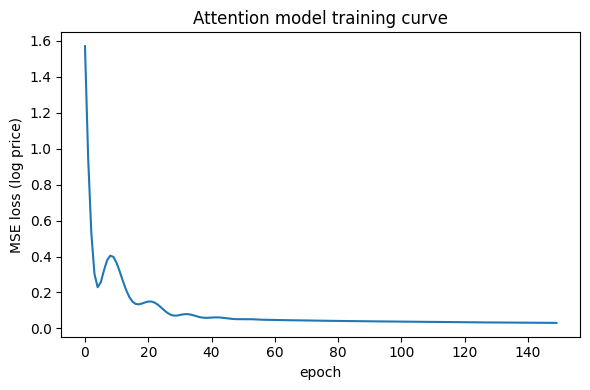

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history)
plt.xlabel('epoch'); plt.ylabel('MSE loss (log price)')
plt.title('Attention model training curve')
plt.tight_layout()
plt.savefig("reports/figures/gnn_training_curve.png", dpi=150)
plt.show()


In [19]:
model.eval()
own_feat_te, neighbor_feat_te, neighbor_price_te, neighbor_dist_te = [t.to(device) for t in test_tensors]
with torch.no_grad():
    pred_log, attn_weights = model(own_feat_te, neighbor_feat_te, neighbor_price_te, neighbor_dist_te)

pred_price = np.expm1(pred_log.cpu().numpy())
true_price = test['price'].values

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
gnn_mape = mean_absolute_percentage_error(true_price, pred_price) * 100
gnn_rmse = np.sqrt(mean_squared_error(true_price, pred_price))
gnn_r2 = r2_score(true_price, pred_price)
print(f"Attention Spatial Model -> MAPE: {gnn_mape:.2f}%  RMSE: ${gnn_rmse:,.0f}  R2: {gnn_r2:.3f}")
np.save("test_pred_price.npy", pred_price)
np.save("test_attn_weights.npy", attn_weights.cpu().numpy())


Attention Spatial Model -> MAPE: 13.69%  RMSE: $124,079  R2: 0.877


In [ ]:
print("pred_log min:", pred_log.min().item())
print("pred_log max:", pred_log.max().item())
print("pred_price min:", pred_price.min())
print("pred_price max:", pred_price.max())

pred_log min: 11.88262939453125
pred_log max: 15.389476776123047
pred_price min: 144729.61
pred_price max: 4825749.0


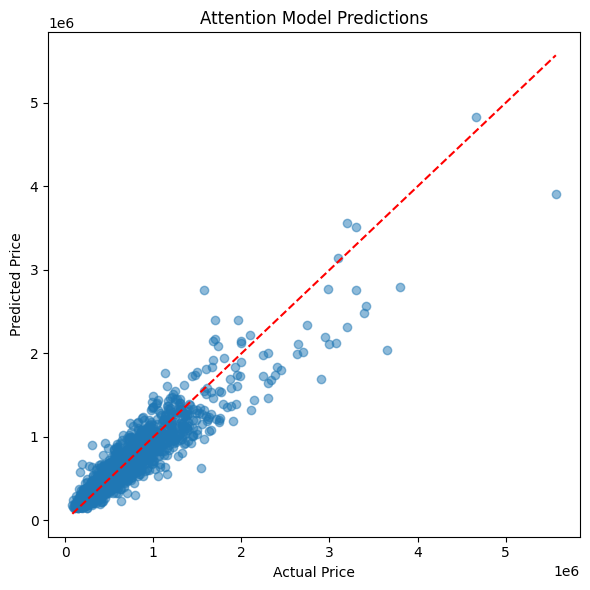

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(true_price, pred_price, alpha=0.5)

plt.plot(
    [true_price.min(), true_price.max()],
    [true_price.min(), true_price.max()],
    "r--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Attention Model Predictions")

plt.tight_layout()

plt.savefig("reports/figures/attention_actual_vs_predicted.png", dpi=150)

plt.show()

In [ ]:
import seaborn as sns

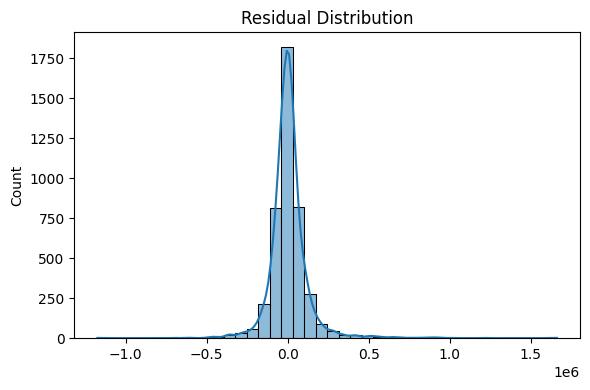

In [ ]:
residuals = true_price - pred_price

plt.figure(figsize=(6,4))

sns.histplot(residuals, bins=40, kde=True)

plt.title("Residual Distribution")

plt.tight_layout()

plt.savefig("reports/figures/attention_residual_distribution.png", dpi=150)

plt.show()

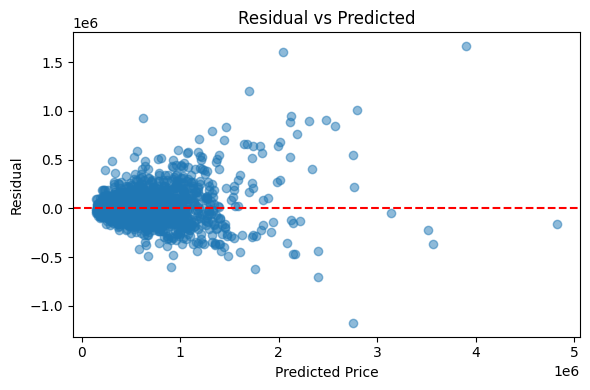

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(pred_price, residuals, alpha=0.5)

plt.axhline(0,color="red",linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual vs Predicted")

plt.tight_layout()

plt.savefig(
    "reports/figures/residual_vs_predicted.png",
    dpi=150
)

plt.show()

In [ ]:
import joblib

joblib.dump(scaler, "models/feature_scaler.pkl")

['models/feature_scaler.pkl']

In [ ]:
metrics = {
    "MAPE": float(gnn_mape),
    "RMSE": float(gnn_rmse),
    "R2": float(gnn_r2),
    "Epochs": EPOCHS,
    "Parameters": sum(p.numel() for p in model.parameters())
}

import json
with open("data/attention_model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [ ]:
prediction_df = pd.DataFrame({
    "Actual Price": true_price,
    "Predicted Price": pred_price,
    "Residual": true_price - pred_price
})

prediction_df["Absolute Error"] = abs(
    prediction_df["Actual Price"] -
    prediction_df["Predicted Price"]
)

prediction_df.to_csv(
    "data/attention_predictions.csv",
    index=False
)

## Day 5 Summary

- Developed a Graph Attention Network (GAT)-inspired spatial valuation model using pure PyTorch.
- Modelled each property as a node attending to its 10 nearest spatial neighbours using Haversine distance.
- Prevented information leakage by restricting neighbour aggregation to training-set properties only.
- Learned neighbour importance dynamically through an attention mechanism instead of assigning equal importance to nearby properties.
- Evaluated the model using RMSE, MAPE and R², and generated prediction outputs, diagnostic plots, trained model checkpoints and evaluation metrics for comparison with baseline machine learning models.